# Lecture 6a — Risk Measures and Their Properties

**25882 AI-powered Investment and Risk Management** · UTS Business School

---

Every risk report ends with a number. This notebook is about **which** number, and why
the choice is not a matter of taste.

We work through three questions:

1. **What are we summarising?** A conditional loss distribution — and $\sigma$, VaR and
   ES are three different summaries of the same object.
2. **Which summaries are safe to use as a limit?** The *coherence* axioms, and a worked
   case where VaR says diversification made things worse.
3. **What actually moves the number?** We compare the choice of measure against the
   choice of distributional assumption, and find the second matters more.

By the end you should be able to defend a risk number to someone who disagrees with it.

### The dataset

We use the **Plotly S&P 500 five-year panel** (February 2013 – February 2018) throughout
Lecture 6. It is small enough for Binder, and it is the dataset behind every figure in the
lecture slides — so your output should match the deck to the decimal. Set `USE_LIVE = True`
below to pull a current window from Yahoo Finance instead; the numbers will differ, and the
Stretch exercises ask you to explain why.

> **A caveat worth stating out loud.** Keeping only tickers with a complete price history
> leaves 470 names and builds in **survivorship bias** — firms that were delisted or
> acquired have been silently removed. Our risk estimates are therefore optimistic. This is
> the single most common flaw in student risk analyses, and it is worth naming before we
> compute anything.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy import stats

import airm6 as a6

USE_LIVE = False          # True -> pull a current window from Yahoo Finance instead

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("airm6 helpers loaded.")

airm6 helpers loaded.


In [2]:
if USE_LIVE:
    prices = a6.get_prices(tickers=["AAPL", "JPM", "XOM", "JNJ", "PG", "NEM"],
                           use_live=True, start="2019-01-01", end=None)
else:
    prices = a6.get_prices()          # the full cached panel

returns = a6.log_returns(prices)
portfolio = a6.portfolio_returns(returns)      # equally weighted, daily rebalanced

print(f"{prices.shape[1]} tickers, {len(returns):,} trading days")
print(f"{returns.index.min().date()} to {returns.index.max().date()}")
print(f"Annualised portfolio volatility: {a6.annualise_vol(portfolio.std()) * 100:.2f}%")

470 tickers, 1,258 trading days
2013-02-11 to 2018-02-07
Annualised portfolio volatility: 12.71%


---
## 1. Three summaries of one distribution

For a loss $L$ over a fixed horizon and a confidence level $\alpha$:

- **Standard deviation** measures dispersion. It is symmetric, so a portfolio that
  occasionally doubles is penalised exactly as much as one that occasionally halves.
- **Value at Risk** is a *quantile*: the loss you exceed with probability $1 - \alpha$.
  It tells you where the tail begins and says nothing about what lies beyond it.
- **Expected Shortfall** is the *average* loss in the worst $1-\alpha$ of cases, so it
  responds to the shape of the tail rather than to a single point of it.

<details>
<summary><b>The formal definitions (click to expand)</b></summary>

$$\sigma = \sqrt{\mathbb{E}\big[(L - \mathbb{E}L)^2\big]}$$

$$\mathrm{VaR}_\alpha(L) = \inf\{\ell : \mathbb{P}(L \le \ell) \ge \alpha\}$$

$$\mathrm{ES}_\alpha(L) = \frac{1}{1-\alpha}\int_\alpha^1 \mathrm{VaR}_u(L)\,du$$

ES is the average of *all* the VaRs beyond $\alpha$, which is the cleanest way to see why
it cannot ignore the far tail.

</details>

The helpers in `airm6` follow one convention consistently: **`confidence` is always a
confidence level** (`0.99` means 99%), and every measure returns a **positive loss
magnitude**. Riskfolio-Lib uses the opposite convention for `alpha`, which we handle in
Section 4.

In [3]:
alpha = 0.99

print(f"Standard deviation (daily)      {portfolio.std() * 100:.3f}%")
print(f"Standard deviation (annualised) {a6.annualise_vol(portfolio.std()) * 100:.2f}%")
print()
print(f"Historical VaR  at {alpha:.1%}      {a6.var_hist(portfolio, alpha) * 100:.3f}%")
print(f"Historical ES   at {alpha:.1%}      {a6.es_hist(portfolio, alpha) * 100:.3f}%")
print()
print(f"Gaussian   VaR  at {alpha:.1%}      {a6.var_normal(portfolio, alpha) * 100:.3f}%")
print(f"Gaussian   ES   at {alpha:.1%}      {a6.es_normal(portfolio, alpha) * 100:.3f}%")

Standard deviation (daily)      0.800%
Standard deviation (annualised) 12.71%

Historical VaR  at 99.0%      2.316%
Historical ES   at 99.0%      3.015%

Gaussian   VaR  at 99.0%      1.820%
Gaussian   ES   at 99.0%      2.092%


Read those two blocks against each other. The historical numbers are noticeably larger than
the Gaussian ones at 99% — the empirical distribution has more weight in the left tail than
a normal distribution fitted to the same data. We quantify that gap properly in Section 3.

Let us look at the distribution the numbers are summarising.

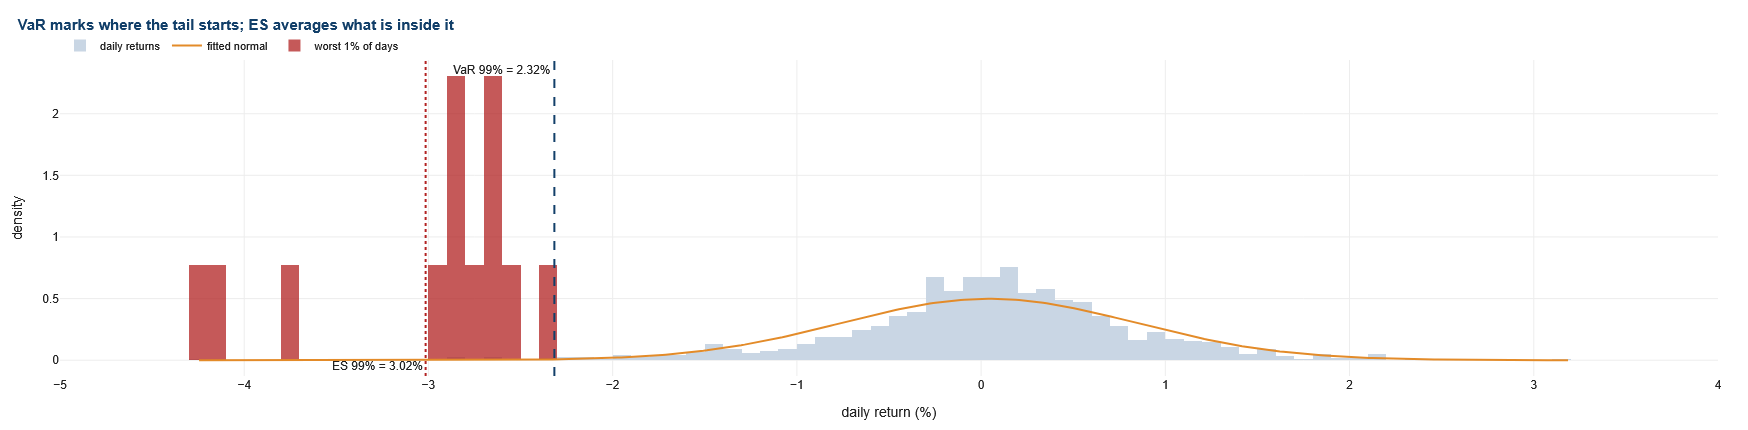

In [4]:
var99 = a6.var_hist(portfolio, 0.99)
es99 = a6.es_hist(portfolio, 0.99)
x = portfolio * 100

fig = go.Figure()
fig.add_trace(go.Histogram(x=x, nbinsx=120, name="daily returns",
                           marker_color="#C9D6E4", histnorm="probability density"))

grid = np.linspace(x.min(), x.max(), 400)
fig.add_trace(go.Scatter(x=grid, y=stats.norm.pdf(grid, x.mean(), x.std()),
                         name="fitted normal", line=dict(color=a6.ORANGE, width=2)))

tail = x[x <= -var99 * 100]
fig.add_trace(go.Histogram(x=tail, nbinsx=30, name="worst 1% of days",
                           marker_color=a6.RED, opacity=0.75,
                           histnorm="probability density"))

fig.add_vline(x=-var99 * 100, line=dict(color=a6.NAVY, width=2, dash="dash"),
              annotation_text=f"VaR 99% = {var99*100:.2f}%", annotation_position="top left")
fig.add_vline(x=-es99 * 100, line=dict(color=a6.RED, width=2, dash="dot"),
              annotation_text=f"ES 99% = {es99*100:.2f}%", annotation_position="bottom left")

a6.style(fig, title="VaR marks where the tail starts; ES averages what is inside it",
         xtitle="daily return (%)", ytitle="density", height=430)
fig.update_layout(barmode="overlay", xaxis_range=[-5, 4])
fig.show()

The orange curve is a normal distribution fitted to the same returns. Notice it sits
*above* the histogram in the shoulders and *below* it in the far left tail: the Gaussian
assumption spreads probability into the middle that actually belongs in the extremes.

**The gap between the two vertical lines is the whole argument for ES.** Every day in the
red region has the same VaR. They do not have the same ES.

---
## 2. Coherence — and watching VaR fail

[Artzner et al. (1999)](https://doi.org/10.1111/1467-9965.00068) asked what properties a
risk measure needs to be usable as a capital requirement, and gave four axioms. Three are
uncontroversial. The fourth is where VaR breaks.

**Subadditivity:** $\rho(L_1 + L_2) \le \rho(L_1) + \rho(L_2)$ — merging two books cannot
create risk.

This is not an aesthetic preference. Without it, a desk can reduce its measured risk by
**splitting a book in two**, and a firm-wide limit becomes unenforceable.

Rather than assert that VaR fails, let us construct the failure.

In [5]:
# Two INDEPENDENT corporate bonds. Each defaults with probability 4%, losing 100.
p_default, loss_given_default, conf = 0.04, 100.0, 0.95

# --- exact loss distributions, by enumeration (no simulation needed) ---
single = pd.Series({0.0: 1 - p_default, loss_given_default: p_default})

pair = {}
for d1 in (0, 1):
    for d2 in (0, 1):
        outcome = loss_given_default * (d1 + d2)
        prob = (p_default if d1 else 1 - p_default) * (p_default if d2 else 1 - p_default)
        pair[outcome] = pair.get(outcome, 0.0) + prob
pair = pd.Series(pair).sort_index()

print("One bond:")
for v, q in single.items():
    print(f"   lose {v:6.0f}  with probability {q:.4f}")
print("\nBoth bonds:")
for v, q in pair.items():
    print(f"   lose {v:6.0f}  with probability {q:.4f}")

One bond:
   lose      0  with probability 0.9600
   lose    100  with probability 0.0400

Both bonds:
   lose      0  with probability 0.9216
   lose    100  with probability 0.0768
   lose    200  with probability 0.0016


In [6]:
def var_discrete(dist, confidence):
    "VaR of a discrete loss distribution: the smallest loss with cumulative prob >= confidence."
    cumulative = dist.sort_index().cumsum()
    return float(cumulative.index[cumulative.to_numpy() >= confidence - 1e-12][0])

def es_discrete(dist, confidence):
    "ES of a discrete loss distribution: probability-weighted mean of the worst tail."
    tail_mass, taken, total = 1 - confidence, 0.0, 0.0
    for value, prob in dist.sort_index(ascending=False).items():
        use = min(prob, tail_mass - taken)
        total += value * use
        taken += use
        if taken >= tail_mass - 1e-15:
            break
    return total / tail_mass

var_one, var_both = var_discrete(single, conf), var_discrete(pair, conf)
es_one, es_both = es_discrete(single, conf), es_discrete(pair, conf)

print(f"VaR{conf:.0%}   one bond = {var_one:6.1f}   two separately = {2*var_one:6.1f}   "
      f"combined = {var_both:6.1f}   -> {'FAILS' if var_both > 2*var_one else 'holds'}")
print(f"ES {conf:.0%}   one bond = {es_one:6.1f}   two separately = {2*es_one:6.1f}   "
      f"combined = {es_both:6.1f}   -> {'holds' if es_both <= 2*es_one else 'FAILS'}")

VaR95%   one bond =    0.0   two separately =    0.0   combined =  100.0   -> FAILS
ES 95%   one bond =   80.0   two separately =  160.0   combined =  103.2   -> holds


Look carefully at what just happened.

A single defaultable bond has $\mathbb{P}(L \le 0) = 0.96 \ge 0.95$, so the 95% quantile
sits at zero: **VaR scores a defaultable bond as riskless.** Hold two of them and
$\mathbb{P}(L \le 0) = 0.9216 < 0.95$, so the quantile jumps to the next outcome and VaR
becomes 100.

$$\mathrm{VaR}_{95}(A) + \mathrm{VaR}_{95}(B) = 0 \;<\; 100 = \mathrm{VaR}_{95}(A+B)$$

**Diversifying increased measured risk from zero to one hundred.** ES behaves properly:
$80 + 80 \ge 103.2$, and it never scored the single bond as riskless in the first place.

A quantile ignores everything past itself. That is the entire defect, and it is why the
Fundamental Review of the Trading Book moved bank capital from 99% VaR to 97.5% ES.

> **The irony worth remembering.** ES is coherent but *not elicitable* — there is no
> scoring function it uniquely minimises. So FRTB computes capital with ES and still
> backtests with VaR. We return to this in Notebook 06c.

---
## 3. What actually moves the number?

There is a lot of argument about VaR versus ES. There is much less argument about the
distributional assumption sitting underneath both — which is unfortunate, because that is
where most of the variation lives.

Let us measure both effects on the same portfolio.

In [7]:
print(f"Skewness           {portfolio.skew():+.2f}")
print(f"Excess kurtosis    {portfolio.kurt():+.2f}   (0 for a normal distribution)")
print()

table = a6.risk_table(portfolio)
display(table.style.format("{:.2f}%")
        .set_caption("Risk measures under three distributional assumptions (daily, %)"))

Skewness           -0.58
Excess kurtosis    +2.71   (0 for a normal distribution)



,VaR 95%,VaR 97.5%,VaR 99%,ES 97.5%
Normal,1.27%,1.53%,1.82%,1.83%
Student-t (nu=3.7),1.17%,1.56%,2.16%,2.31%
Empirical,1.40%,1.74%,2.32%,2.42%


In [8]:
normal_var975 = table.loc["Normal", "VaR 97.5%"]
normal_es975 = table.loc["Normal", "ES 97.5%"]
empirical_es975 = table.loc["Empirical", "ES 97.5%"]

change_measure = 100 * (normal_es975 / normal_var975 - 1)
change_assumption = 100 * (empirical_es975 / normal_es975 - 1)

print(f"Hold the assumption fixed (normal), change the MEASURE  VaR->ES : {change_measure:+.0f}%")
print(f"Hold the measure fixed (ES 97.5%), change the ASSUMPTION        : {change_assumption:+.0f}%")

Hold the assumption fixed (normal), change the MEASURE  VaR->ES : +20%
Hold the measure fixed (ES 97.5%), change the ASSUMPTION        : +32%


**The assumption moves the number substantially more than the measure does.**

Notice also the Student-$t$ row crossing over: it sits *below* the normal at 95% and well
*above* it at 99%. Fat tails redistribute probability — they do not simply add to it. A
model that is conservative at one confidence level can be aggressive at another.

The practical lesson: arguing about VaR versus ES while assuming normality is arguing about
the smaller of your two errors. Notebook 06b is therefore about estimating the
**distribution**, not the summary.

---
## 4. Riskfolio-Lib's risk measure library

Riskfolio-Lib implements a large family of risk measures, and we use it heavily in
Notebook 06d. Two things to get right before you do.

**First, the `alpha` convention is inverted.** In `airm6` and on the slides, `confidence`
is a confidence level. In Riskfolio-Lib, `alpha` is the **tail probability**. So 99%
confidence is `alpha=0.01`. Getting this backwards is the most common error when moving
between the two, and it fails silently — you get a plausible-looking number that is wrong.

**Second, most of these measures are not interchangeable.** They look at different parts of
the distribution, and only some are coherent.

In [9]:
import riskfolio as rp

frame = portfolio.to_frame("Portfolio")
confidence = 0.99

theirs = float(rp.RiskFunctions.VaR_Hist(frame, alpha=a6.rp_alpha(confidence)))

print(f"rp.VaR_Hist(alpha={a6.rp_alpha(confidence)})                    {theirs * 100:.4f}%")
print(f"airm6.var_hist(confidence={confidence}, method='lower')  "
      f"{a6.var_hist(portfolio, confidence, method='lower') * 100:.4f}%   <- same convention")
print(f"airm6.var_hist(confidence={confidence})                  "
      f"{a6.var_hist(portfolio, confidence) * 100:.4f}%   <- default (interpolated)")
print()
print("Now the error you are actually at risk of making:")
print(f"   rp.VaR_Hist(alpha=0.99) = "
      f"{float(rp.RiskFunctions.VaR_Hist(frame, alpha=0.99)) * 100:.4f}%")

rp.VaR_Hist(alpha=0.01)                    2.3281%
airm6.var_hist(confidence=0.99, method='lower')  2.3281%   <- same convention
airm6.var_hist(confidence=0.99)                  2.3164%   <- default (interpolated)

Now the error you are actually at risk of making:
   rp.VaR_Hist(alpha=0.99) = -2.0163%


In [10]:
measures = {
    "Standard deviation":       lambda f: float(np.std(f.to_numpy(), ddof=1)),
    "Mean absolute deviation":  lambda f: float(rp.RiskFunctions.MAD(f)),
    "Semi standard deviation":  lambda f: float(rp.RiskFunctions.SemiDeviation(f)),
    "VaR (historical)":         lambda f: float(rp.RiskFunctions.VaR_Hist(f, alpha=0.01)),
    "CVaR / ES (historical)":   lambda f: float(rp.RiskFunctions.CVaR_Hist(f, alpha=0.01)),
    "EVaR (entropic)":          lambda f: float(rp.RiskFunctions.EVaR_Hist(f, alpha=0.01)[0]),
    "Worst realisation":        lambda f: float(rp.RiskFunctions.WR(f)),
    "Max drawdown":             lambda f: float(rp.RiskFunctions.MDD_Abs(f)),
    "Conditional drawdown":     lambda f: float(rp.RiskFunctions.CDaR_Abs(f, alpha=0.01)),
    "Ulcer index":              lambda f: float(rp.RiskFunctions.UCI_Abs(f)),
}

rows = {}
for name, fn in measures.items():
    try:
        rows[name] = fn(frame) * 100
    except Exception as exc:
        rows[name] = np.nan
        print(f"  ({name} unavailable in this version: {type(exc).__name__})")

summary = pd.Series(rows, name="value (%)").to_frame()
summary["coherent?"] = ["yes", "yes", "yes", "NO", "yes", "yes",
                        "yes", "no", "yes", "no"]
display(summary.style.format({"value (%)": "{:.3f}"})
        .set_caption("Riskfolio-Lib risk measures on the same portfolio, at 99% confidence"))

,value (%),coherent?
Standard deviation,0.800,yes
Mean absolute deviation,0.577,yes
Semi standard deviation,0.598,yes
VaR (historical),2.328,NO
CVaR / ES (historical),3.038,yes
EVaR (entropic),3.580,yes
Worst realisation,4.245,yes
Max drawdown,20.596,no
Conditional drawdown,18.063,yes
Ulcer index,4.196,no


Two conventions, one measure. Riskfolio takes the **order statistic** directly; `airm6`
**interpolates** between order statistics by default. On this sample they differ by roughly
a basis point — immaterial here, but it is exactly the kind of discrepancy that turns into
an afternoon of debugging when your number will not match a vendor system. Neither is
wrong; they answer slightly different questions about a discrete sample.

The second number is the one that should worry you. Passing `alpha=0.99` returns a
**negative** VaR, because you have asked for the 99th percentile of *returns* rather than
the 1st. It does not raise an error. It just quietly reports that your portfolio cannot
lose money.

---
Two observations on the table above.

The **drawdown** measures are an order of magnitude larger than the others, because they
describe a *cumulative path* rather than a single period. Comparing a max drawdown with a
daily VaR is a category error, and it is a surprisingly common one in student reports.

Only one row is marked `NO` for coherence — and it is the one still used most widely.

---
## Exercises

### Core

**C1.** Recompute the Section 3 table at 99% instead of 97.5%. Does the assumption still
matter more than the measure? Report both percentage changes.

**C2.** In the two-bond example, raise the default probability from 4% to 6% and recompute.
Does VaR still fail subadditivity at 95%? Explain, in one sentence, what changed.

**C3.** Compute historical ES at 97.5% for each of the six tickers `AAPL, JPM, XOM, JNJ,
PG, NEM` individually, and for the equally weighted portfolio of the six. Is the portfolio
ES less than the average of the individual ESs? Which axiom does that illustrate?

### Stretch

**S1.** The two-bond example assumed independence. Introduce a default correlation by
simulating from a bivariate Gaussian copula, and find the correlation at which VaR *stops*
failing subadditivity at 95%. Comment on what that implies for a firm that reports VaR
across weakly correlated desks.

**S2.** Set `USE_LIVE = True` and rerun the notebook on a 2019–present window that includes
March 2020. Which rows of the Section 3 table change most, and why does the Student-$t$
crossover point move?

**S3.** VaR fails subadditivity but ES is not elicitable. Read the abstract of
[Nolde and Ziegel (2017)](https://doi.org/10.1214/17-AOAS1041) and write a paragraph
arguing either that a regulator should prefer a coherent-but-unscoreable measure, or that
it should prefer a scoreable-but-incoherent one. Your answer will be more convincing if you
name the specific failure each choice exposes you to.